In [ ]:
!pip install geopy
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from geopy.distance import geodesic

# Load and clean data
df = pd.read_csv('/content/Mineral ores round the world.csv', low_memory=False)
df.columns = df.columns.str.strip().str.lower()

# Keep only India records and valid coordinates
df = df.dropna(subset=['latitude', 'longitude'])
df = df[df['country'].str.lower() == 'india']
df[['latitude', 'longitude']] = df[['latitude', 'longitude']].astype(float)

# Drop rows with unknown or missing commod1, district, or state
for col in ['commod1', 'district', 'state']:
    if col in df.columns:
        df = df[df[col].notna()]
        df = df[df[col].str.strip().str.lower() != 'unknown']

# Handle quantity column
has_quantity = 'quantity' in df.columns and df['quantity'].notna().all()
if has_quantity:
    df['quantity'] = df['quantity'].astype(float)

# Prepare positive samples
ore_df = df[['latitude', 'longitude']].copy()
ore_df['ore_present'] = 1

# Generate random negative samples within India
np.random.seed(42)
negative_samples = pd.DataFrame({
    'latitude': np.random.uniform(8, 37, len(ore_df)),
    'longitude': np.random.uniform(68, 97, len(ore_df)),
    'ore_present': 0
})

# Combine for training
X = pd.concat([ore_df[['latitude', 'longitude']], negative_samples[['latitude', 'longitude']]])
y = pd.concat([ore_df['ore_present'], negative_samples['ore_present']])
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Ore locator function
def find_ores_by_coords(lat, lon):
    prediction = model.predict([[lat, lon]])[0]
    if prediction == 1:
        print(f"\n🧠 Model suggests ores **might be present** at coordinates ({lat}, {lon}).")
    else:
        print(f"\n🔍 Ore is **unlikely** to be present at coordinates ({lat}, {lon}), but here are nearby ore locations:")

    # Calculate distances
    df['distance_km'] = df.apply(lambda row: geodesic((lat, lon), (row['latitude'], row['longitude'])).km, axis=1)
    nearest = df.sort_values('distance_km').head(5)

    print("\n📍 Nearest known ore locations:")
    for _, row in nearest.iterrows():
        state = row.get('state', 'Unknown state')
        mineral = row.get('commod1', 'Unknown mineral')
        site = row.get('site_name', 'Unknown site') if pd.notna(row.get('site_name')) else 'Unknown site'
        coords = f"({row['latitude']}, {row['longitude']})"
        dist = round(row['distance_km'], 2)

        if has_quantity:
            qty = int(row['quantity'])
            print(f"🧭 {state} → {mineral} ({qty} tons) at {site} {coords} — {dist} km away")
        else:
            print(f"🧭 {state} → {mineral} at {site} {coords} — {dist} km away")

# Interactive input loop
while True:
    try:
        lat_input = input("\nEnter latitude (or type 'exit' to quit): ").strip()
        if lat_input.lower() == 'exit':
            print("🔚 Exiting.")
            break

        lon_input = input("Enter longitude: ").strip()
        if lon_input.lower() == 'exit':
            print("🔚 Exiting.")
            break

        lat = float(lat_input)
        lon = float(lon_input)

        find_ores_by_coords(lat, lon)

    except ValueError:
        print("⚠️ Please enter valid numeric values for latitude and longitude.")



Enter latitude (or type 'exit' to quit): 22.0797
Enter longitude: 82.1409


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



🧠 Model suggests ores **might be present** at coordinates (22.0797, 82.1409).

📍 Nearest known ore locations:
🧭 Madhya Pradesh → Aluminum at (Facility) Korba Refinery (22.36612, 82.76697) — 71.92 km away
🧭 Bihar → Aluminum at Lohardaga (22.69939, 81.7003) — 82.26 km away
🧭 Madhya Pradesh → Aluminum at Amarkantak (22.81608, 81.717) — 92.48 km away
🧭 Orissa → Aluminum at (Facility) Damanjodi Refinery (21.03284, 82.83357) — 136.32 km away
🧭 Madhya Pradesh → Copper at Malanjhkhand Mine (22.01612, 80.717) — 147.15 km away

Enter latitude (or type 'exit' to quit): 20.5815
Enter longitude: 81.0711


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



🧠 Model suggests ores **might be present** at coordinates (20.5815, 81.0711).

📍 Nearest known ore locations:
🧭 Madhya Pradesh → Manganese at Enkatola (21.36618, 80.16701) — 128.01 km away
🧭 Maharashtra → Vanadium at Maharashtra State (21.13283, 79.68365) — 156.76 km away
🧭 Madhya Pradesh → Manganese at Piparia (21.74948, 80.16701) — 159.81 km away
🧭 Madhya Pradesh, Maharashtra → Manganese at Madhya Pradesh and Maharashtra States (21.83277, 80.30034) — 159.99 km away
🧭 Madhya Pradesh → Manganese at Kot Pahar (21.89114, 80.40866) — 160.48 km away

Enter latitude (or type 'exit' to quit): 23.6913
Enter longitude: 85.2722


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



🧠 Model suggests ores **might be present** at coordinates (23.6913, 85.2722).

📍 Nearest known ore locations:
🧭 Bihar → Aluminum at Bagru Hills (23.56601, 84.60023) — 69.96 km away
🧭 West Bengal → REE at Ranchi-Purulia (23.41602, 86.0002) — 80.34 km away
🧭 Bihar → Kyanite at Lapso Buru Mine (22.83271, 85.41687) — 96.23 km away
🧭 Bihar → Graphite at Khamdih (23.96598, 84.21694) — 111.74 km away
🧭 Bihar → Graphite at Sokra (23.96598, 84.13354) — 119.94 km away

Enter latitude (or type 'exit' to quit): ranchi
Enter longitude: ranchi
⚠️ Please enter valid numeric values for latitude and longitude.

Enter latitude (or type 'exit' to quit): 23.3441
Enter longitude: 85.3096


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



🧠 Model suggests ores **might be present** at coordinates (23.3441, 85.3096).

📍 Nearest known ore locations:
🧭 Bihar → Kyanite at Lapso Buru Mine (22.83271, 85.41687) — 57.69 km away
🧭 West Bengal → REE at Ranchi-Purulia (23.41602, 86.0002) — 71.05 km away
🧭 Bihar → Aluminum at Bagru Hills (23.56601, 84.60023) — 76.53 km away
🧭 Madhya Pradesh → Aluminum, Contained or Metal at Korba (22.36612, 84.76692) — 121.78 km away
🧭 Bihar → Iron at Gua Mines (22.2161, 85.38353) — 125.15 km away

Enter latitude (or type 'exit' to quit): exit
🔚 Exiting.


In [ ]:
! pip install scikit-learn pandas matplotlib

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC  # Support Vector Classifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()
X = iris.data      # features
y = iris.target    # labels

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target_names'] = df['target'].apply(lambda x: iris.target_names[x])




print(df.head())
# Split the Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and Train the SVM Model


model = SVC(kernel='linear')  # You can also try 'rbf', 'poly', etc.
model.fit(X_train, y_train)

# Make Predictions

y_pred = model.predict(X_test)


# Evaluate the Model

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Predict on New Data

new_data = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(new_data)
print("Predicted Class:", iris.target_names[prediction[0]])

<ipython-input-4-a5f723b31814>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['latitude', 'longitude']] = df[['latitude', 'longitude']].astype(float)


Ore Presence Prediction Accuracy: 0.4

Classification Report:
                                                                          precision    recall  f1-score   support

Argentite, Chalcopyrite, Galena, Pyrite, Pyrrhotite, Silver, Sphalerite       0.00      0.00      0.00         0
                                                                Bauxite       0.50      0.67      0.57         3
                           Birnessite, Braunite, Pyrolusite, Todorokite       0.00      0.00      0.00         1
                                         Bixbyite, Braunite, Pyrolusite       0.00      0.00      0.00         1
                                                     Boehmite, Gibbsite       0.00      0.00      0.00         1
                                                               Braunite       0.00      0.00      0.00         0
                             Braunite, Jacobsite, Manganite, Pyrolusite       1.00      1.00      1.00         2
                                

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

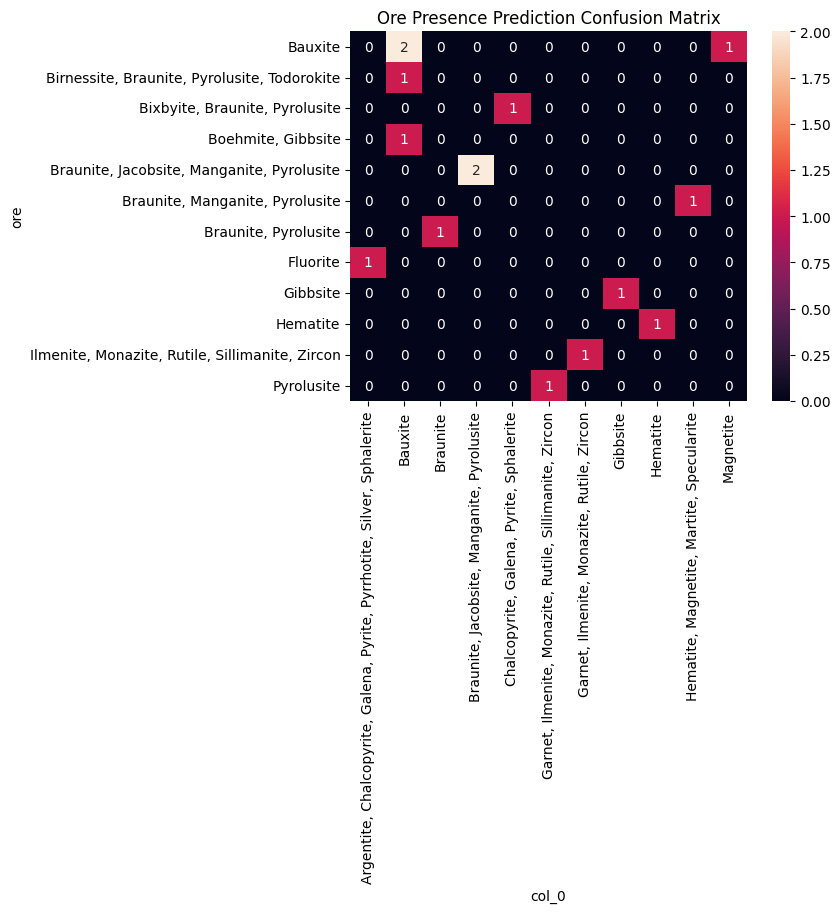

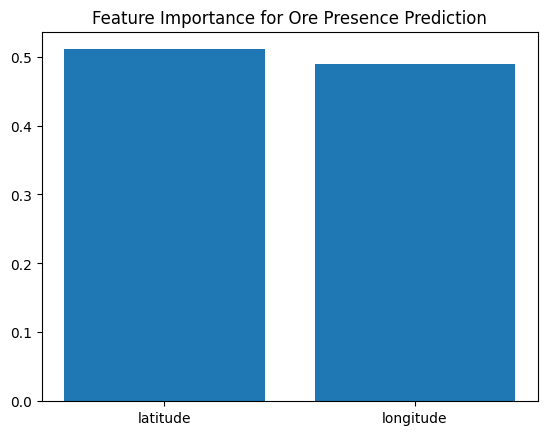

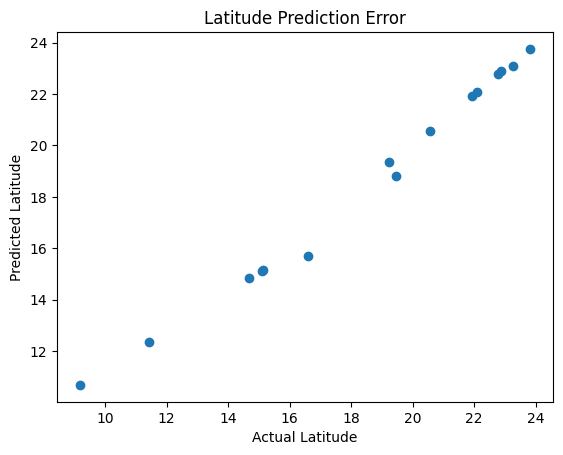

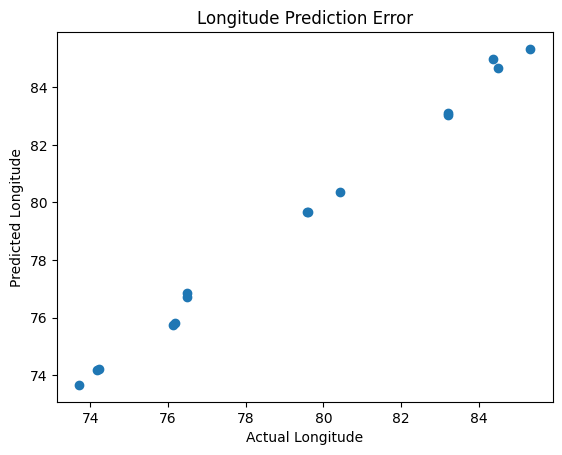

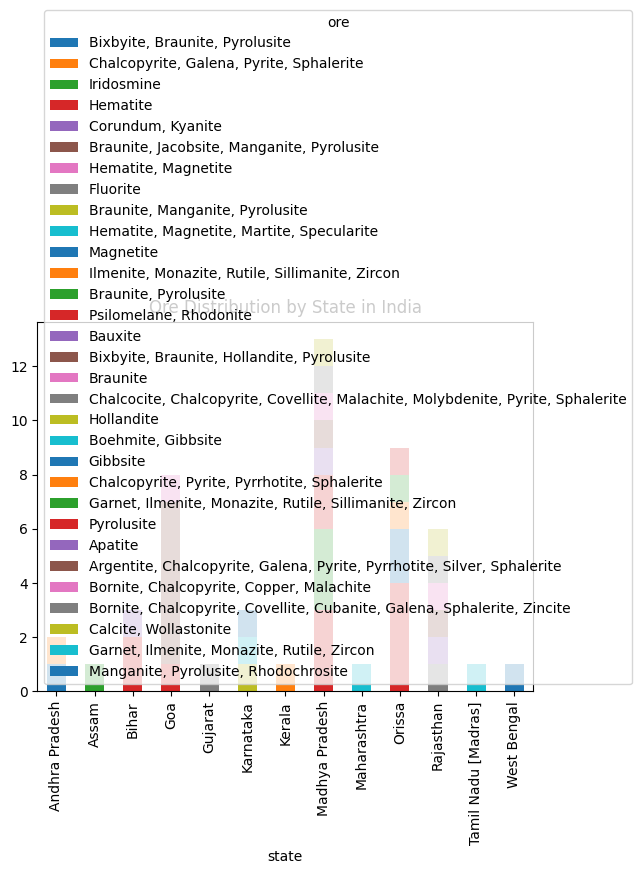

In [ ]:
!pip install geopy pandas scikit-learn matplotlib seaborn geopandas plotly

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, accuracy_score, mean_squared_error
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import plotly.express as px


# 1. Load and Prepare Your Dataset

df = pd.read_csv('/content/Mineral ores round the world.csv', low_memory=False)
df.columns = df.columns.str.strip().str.lower()
df = df.dropna(subset=['latitude', 'longitude', 'ore'])  # Drop rows with missing values
df = df[df['country'].str.lower() == 'india']
df[['latitude', 'longitude']] = df[['latitude', 'longitude']].astype(float)

# 2. Feature Engineering (if needed)

# You can add more features here if necessary, e.g., geological properties, etc.

# 3. Model Training

# Split data into training and testing sets
X = df[['latitude', 'longitude']]
y_ore = df['ore']  # Target variable for ore presence
y_lat = df['latitude']  # Target variable for latitude
y_lon = df['longitude']  # Target variable for longitude

X_train, X_test, y_ore_train, y_ore_test, y_lat_train, y_lat_test, y_lon_train, y_lon_test = train_test_split(
    X, y_ore, y_lat, y_lon, test_size=0.2, random_state=42
)

# Train models
ore_model = RandomForestClassifier(n_estimators=100, random_state=42)
ore_model.fit(X_train, y_ore_train)

lat_model = RandomForestRegressor(n_estimators=100, random_state=42)
lat_model.fit(X_train, y_lat_train)

lon_model = RandomForestRegressor(n_estimators=100, random_state=42)
lon_model.fit(X_train, y_lon_train)


# 4. Model Evaluation and Visualizations

# Ore Presence Prediction
y_ore_pred = ore_model.predict(X_test)
print("Ore Presence Prediction Accuracy:", accuracy_score(y_ore_test, y_ore_pred))
print("\nClassification Report:\n", classification_report(y_ore_test, y_ore_pred))

# Latitude/Longitude Prediction
y_lat_pred = lat_model.predict(X_test)
y_lon_pred = lon_model.predict(X_test)
lat_mse = mean_squared_error(y_lat_test, y_lat_pred)
lon_mse = mean_squared_error(y_lon_test, y_lon_pred)
print("\nLatitude Prediction MSE:", lat_mse)
print("Longitude Prediction MSE:", lon_mse)

# Visualizations

# 2. Ore Presence Prediction Accuracy (Confusion Matrix)
sns.heatmap(pd.crosstab(y_ore_test, y_ore_pred), annot=True, fmt='d')
plt.title('Ore Presence Prediction Confusion Matrix')
plt.show()

# 3. Feature Importance (Bar Chart)
importances = ore_model.feature_importances_
features = X.columns
plt.bar(features, importances)
plt.title('Feature Importance for Ore Presence Prediction')
plt.show()

# 4. Latitude/Longitude Prediction Error (Scatter Plot)
plt.scatter(y_lat_test, y_lat_pred)
plt.xlabel('Actual Latitude')
plt.ylabel('Predicted Latitude')
plt.title('Latitude Prediction Error')
plt.show()

plt.scatter(y_lon_test, y_lon_pred)
plt.xlabel('Actual Longitude')
plt.ylabel('Predicted Longitude')
plt.title('Longitude Prediction Error')
plt.show()

# 5. Ore Distribution by Region (Bar Chart)
# (Assuming you have a 'state' or 'region' column in your dataset)
# Replace 'state' with the actual column name if different
ore_distribution = df.groupby('state')['ore'].value_counts().unstack().fillna(0)
ore_distribution.plot(kind='bar', stacked=True)
plt.title('Ore Distribution by State in India')
plt.show()